KATEGORI D

Batas Kuantil:
Q1 (33.33%) = 3,710,000.00
Q2 (66.67%) = 5,192,936.00

Distribusi Kategori:
Kategori
Murah     186
Sedang    177
Mewah     182
Name: count, dtype: int64


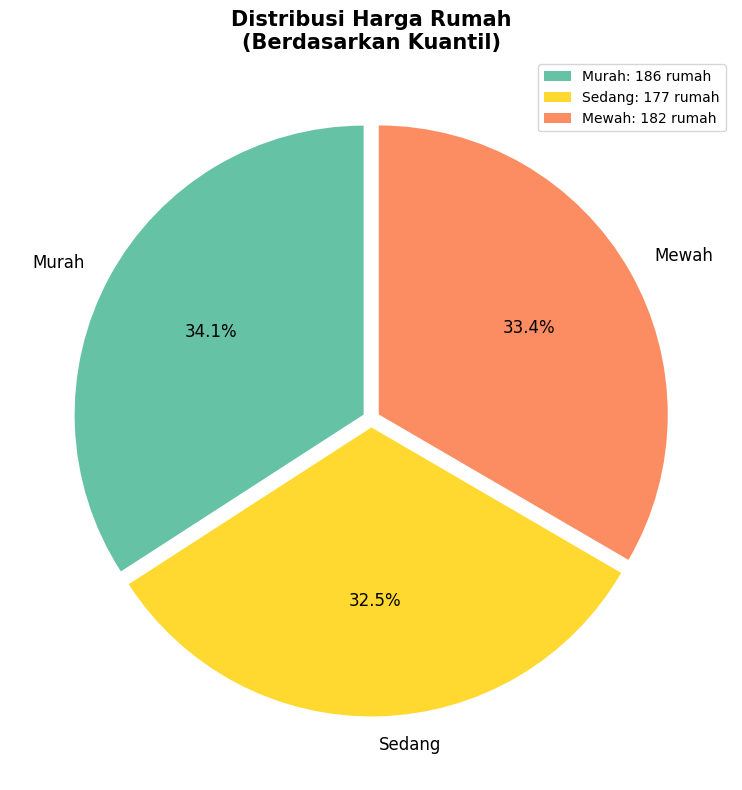

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data CSV
df = pd.read_csv("Kelas C_Housing.csv")

# Ganti 'price' jika nama kolom harga berbeda
harga = df['price']

# Menentukan batas kuantil
q1 = harga.quantile(0.3333)
q2 = harga.quantile(0.6667)

# Fungsi pengelompokan
def kategori_harga(x):
    if x <= q1:
        return 'Murah'
    elif x <= q2:
        return 'Sedang'
    else:
        return 'Mewah'

# Menambahkan kolom kategori
df['Kategori'] = harga.apply(kategori_harga)

# Menghitung jumlah tiap kategori
distribusi = df['Kategori'].value_counts()

# Mengurutkan kategori
distribusi = distribusi.reindex(['Murah', 'Sedang', 'Mewah'])

# Menampilkan hasil
print("Batas Kuantil:")
print(f"Q1 (33.33%) = {q1:,.2f}")
print(f"Q2 (66.67%) = {q2:,.2f}")

print("\nDistribusi Kategori:")
print(distribusi)

# Membuat Pie Chart
plt.figure(figsize=(8,8))

colors = ['#66c2a5', '#ffd92f', '#fc8d62']

plt.pie(
    distribusi,
    labels=distribusi.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0.03, 0.03, 0.03),
    textprops={'fontsize':12}
)

plt.title(
    'Distribusi Harga Rumah\n(Berdasarkan Kuantil)',
    fontsize=15,
    fontweight='bold'
)

plt.legend(
    [f'{i}: {j} rumah' for i, j in zip(distribusi.index, distribusi)],
    loc='best'
)

plt.tight_layout()

plt.savefig(
    'PieChart_HargaRumah.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()